In [55]:
words = open('names.txt' , 'r').read().splitlines()

In [56]:
chars = sorted(list(set(''.join(words))))

In [57]:
import torch

In [58]:
len(words)

32033

In [59]:
min(len(w) for w in words)

2

In [60]:
max(len(w) for w in words)

15

In [61]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']   # -> for a word w [emma] -> [<s>, e,m,m,a,<e>]
    for ch1, ch2 in zip(chs, chs[1:]):  
        bigram = (ch1, ch2)  #emma -> <S>e , em , mm , ma , a<E>
        b[bigram] = b.get(bigram, 0) + 1

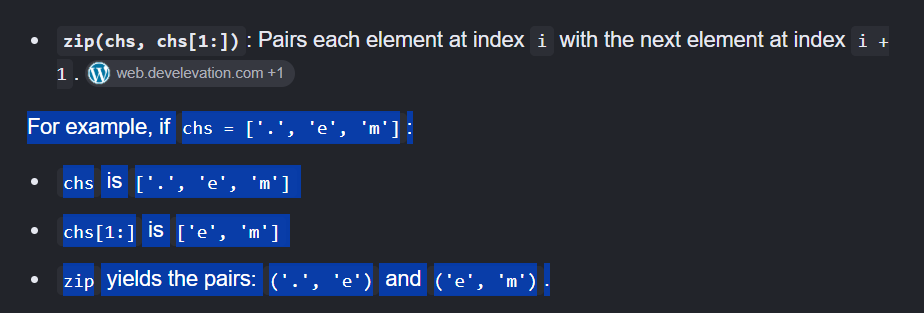

In [63]:
b = sorted(b.items(), key = lambda kv: -kv[1])  # -[kv] sort in descending order kv[1] means sort by count val and not key from items

In [64]:
# using torch to create a bigram table

In [65]:
N = torch.zeros((27, 27), dtype=torch.int32)

In [66]:
chars = sorted(list(set(''.join(words))))
len(chars)

26

In [67]:
chars = sorted(list(set(''.join(words))))    # all unique char - 26 alphabets
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0    # -> <e>a will never occur and a<s> will never occur either so we just use . so our lookup table will hav unnecessary rows
itos = {i:s for s,i in stoi.items()}

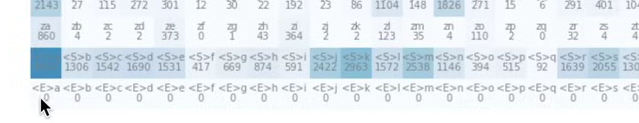
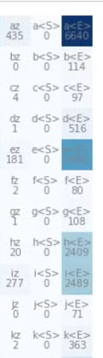

In [69]:
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1, ix2] += 1
    

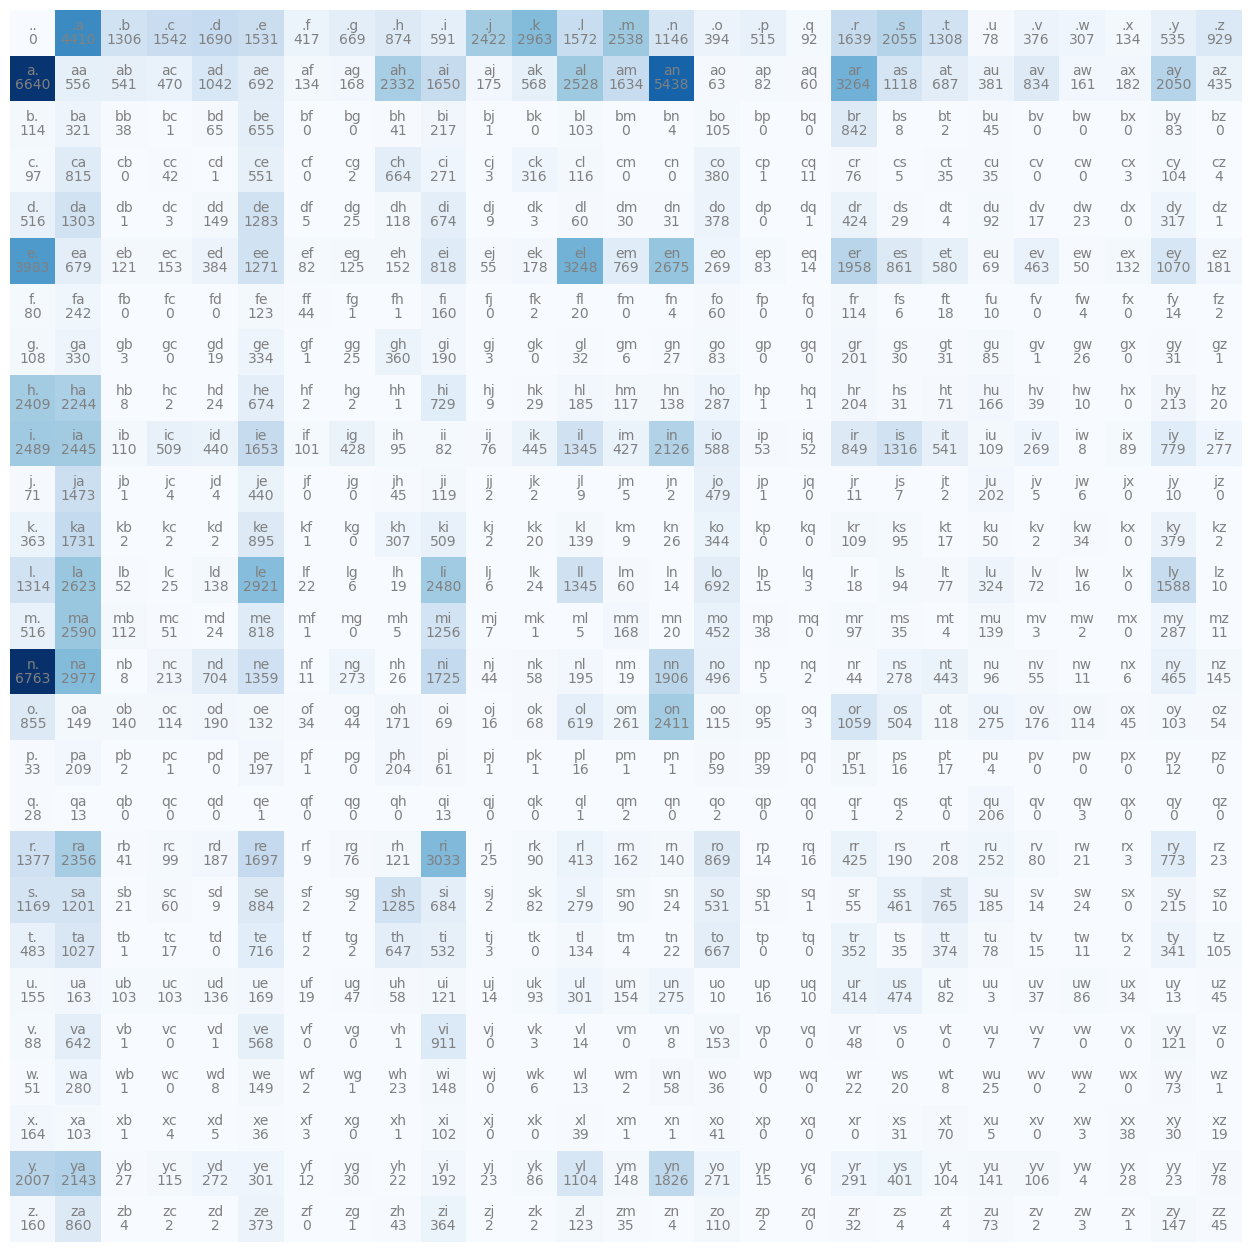

In [70]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [71]:
N[0]  # rows with starting alphabets

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [72]:
N[:,0] # with ending alphabets

tensor([   0, 6640,  114,   97,  516, 3983,   80,  108, 2409, 2489,   71,  363,
        1314,  516, 6763,  855,   33,   28, 1377, 1169,  483,  155,   88,   51,
         164, 2007,  160], dtype=torch.int32)

to get their probability distribution

### Learniing about multinomial , generator

In [75]:
p = N[0].float()
p = p / p.sum()   # probablility of the alphabet occuring first (count over sum of that row)
p 

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [76]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()  
itos[ix]

'j'

- torch.**Generator()**.manual_seed(2147483647): Creates a random number generator and sets a specific seed so the random choices are repeatable.- 
torch.multinomial(p, num_samples=1, replacement=True, generator=g): Picks one index (num_samples=1) from a probability distribution tensor p using sampling with replacement
- 
.item(): Extracts the single chosen number from the PyTorch tensor as a standard Python intege
- .
itos[ix]: Uses that random index to look up a character or word from a vocabulary list (itos meaning index-to-string).


In [78]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)    # random numbers
p = p / p.sum()
torch.multinomial(p, num_samples=100, replacement=True, generator=g)

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 2, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
        0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1, 0,
        0, 1, 1, 1])

### learning about broadcasting semantics
- https://docs.pytorch.org/docs/2.13/notes/broadcasting.html

In [80]:
P = (N).float()
P[0]

tensor([   0., 4410., 1306., 1542., 1690., 1531.,  417.,  669.,  874.,  591.,
        2422., 2963., 1572., 2538., 1146.,  394.,  515.,   92., 1639., 2055.,
        1308.,   78.,  376.,  307.,  134.,  535.,  929.])

<a id="smoothing"></a>

In [81]:
P = (N+1).float()  #laplace smoothing 
P[0]

tensor([1.0000e+00, 4.4110e+03, 1.3070e+03, 1.5430e+03, 1.6910e+03, 1.5320e+03,
        4.1800e+02, 6.7000e+02, 8.7500e+02, 5.9200e+02, 2.4230e+03, 2.9640e+03,
        1.5730e+03, 2.5390e+03, 1.1470e+03, 3.9500e+02, 5.1600e+02, 9.3000e+01,
        1.6400e+03, 2.0560e+03, 1.3090e+03, 7.9000e+01, 3.7700e+02, 3.0800e+02,
        1.3500e+02, 5.3600e+02, 9.3000e+02])

why (N+1)
- If a bigram has a raw count of 0, its calculated probability will be 0. 
- Later, when evaluating the model using negative log-likelihood loss, taking the logarithm of zero log(0) results in negative infinity (-inf) or nan, which breaks the model training/evaluation.


In [83]:
P /= P.sum(1, keepdims=True)

##### what happens if keepdims=False

In [85]:
P /= P.sum(1) # default = False

In [86]:
P.shape

torch.Size([27, 27])

In [87]:
P.sum(1).shape

torch.Size([27])

In [88]:
P.sum(1)    # it will copy these to all rows which results in garbase results

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

In [89]:
P.sum(1,keepdims=True).shape #I have one sum for each of the 27 rows."

torch.Size([27, 1])

In [90]:
P.sum(1,keepdims=True)

tensor([[1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000]])

In [91]:
#what it does  without keepdims
#   P = P/P.sum(1)
#  P =         [27 , 27]
#  P.sum(1) - [_ , 27]   # acc to broadcasting semantics it will go from the right (trailing)
# Broadcasting aligns from the right, so each row's sum is copied across all 27 columns of that row.
 

In [92]:
# with keepdims
# P.sum(1, keepdim=True) gives the sum of each row.
# The resulting [27, 1] is broadcast across the 27 columns of each row,
# because that sum belongs to that particular row.

#### results without keepdim

In [94]:
# resuls without keepdim
P = (N+1).float()
P /= P.sum(1) # default = False

In [95]:
g = torch.Generator().manual_seed(2147483647)
for i in range(10):
  
  out = []
  ix = 0
  while True:
    p = P[ix]
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

juwidedigwaquzopruffyobinn.
fovinttophows.
gwevisliniauwabileviackhbduinrwiqulysstyicaylaftezuffuumestfodoumjuppptsuwahouzzqucore.
ysezockhawavedinerimoufbwynin.
thapsn.
mppimopsuxxxdgossmpttavicuqujumufothotorkyrslu.
igumubri.
mmevujemahuxxwyubevavickarr.
wdohufforta.
mppydabelyuquiqumuwpockazhemimayawathub.


#### results without keepdim

In [97]:
# results with keepdim
P = (N+1).float()
P /= P.sum(1, keepdims=True)

In [98]:
g = torch.Generator().manual_seed(2147483647)
for i in range(10):
  
  out = []
  ix = 0
  while True:
    p = P[ix]
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

junide.
janasah.
p.
cony.
a.
nn.
kohin.
tolian.
juee.
ksahnaauranilevias.


In [99]:
a = 2
print(f"{a=}")

a=2


### introduction to likelihood

- the use of likelihood (and subsequently log likelihood) as the primary metric is for  evaluating how well a language model fits the data
- The likelihood represents the probability of the entire dataset given the model's parameters.
- The likelihood of the entire dataset is calculated as the product of individual probabilities.
- Because probabilities are small numbers between 0 and 1, multiplying many of them together results in extremely tiny, unwieldy values. so we use log
- Maximizing the likelihood is the goal. Because the logarithm is a monotonic function, maximizing the log likelihood is equivalent to maximizing the original likelihood. In machine learning, it is standard to minimize a loss, so we negate the value to create the negative log likelihood

log
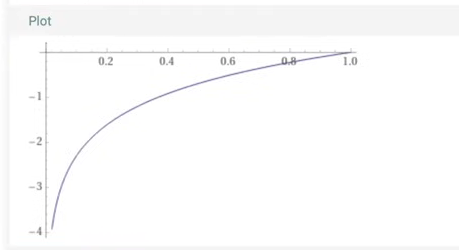
exp 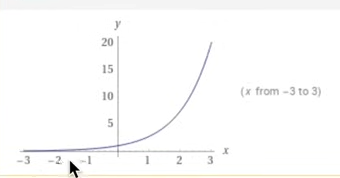

In [103]:
# GOAL: maximize likelihood of the data w.r.t. model parameters (statistical modeling)
# equivalent to maximizing the log likelihood (because log is monotonic)
# equivalent to minimizing the negative log likelihood
# equivalent to minimizing the average negative log likelihood

# log(a*b*c) = log(a) + log(b) + log(c)

In [508]:
log_likelihood = 0.0
n = 0

for w in words:
#for w in ["sanmi"]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    logprob = torch.log(prob)
    log_likelihood += logprob
    n += 1
    #print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

log_likelihood=tensor(-559951.5625)
nll=tensor(559951.5625)
2.4543561935424805


<a id="loss-count"></a>

In [510]:
nll/n

tensor(2.4544)

In [448]:
for w in words[:1]:
#for w in ["sanmi"]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2] # a prob tensor that contains all the probablilites for the cells ( count for now)
    logprob = torch.log(prob) # log of that prob
    log_likelihood += logprob # add
    n += 1  # to normalize 
    #print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

log_likelihood=tensor(-42.0857)
nll=tensor(42.0857)
2.6303577423095703


In [452]:
# create the training set of bigrams (x,y)
xs, ys = [], []
for w in words[:1]:
#for w in ['sanmi']:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    print(ch1, ch2)
    xs.append(ix1)
    ys.append(ix2)
xsT = torch.Tensor(xs)   
xs = torch.tensor(xs)  # small t tensor creates the same int type but Tensor converts to float
ys = torch.tensor(ys)

. e
e m
m m
m a
a .


In [107]:
xs,xsT

(tensor([ 0,  5, 13, 13,  1]), tensor([ 0.,  5., 13., 13.,  1.]))

In [108]:
xs.dtype , xsT.dtype

(torch.int64, torch.float32)

float  is not good, since we need incides in int and not in float so we will run into an error while one hot encoding 


```
---------------------------------------------------------------------------
RuntimeError                              Traceback (most recent call last)
Cell In[133], line 2
      1 import torch.nn.functional as F
----> 2 xenc = F.one_hot(xs, num_classes=27).float()
      3 xenc

RuntimeError: one_hot is only applicable to index 
```tensor.

In [111]:
ys.dtype

torch.int64

In [112]:
ys

tensor([ 5, 13, 13,  1,  0])

Neural networks are made of neurons that perform linear operations, such as matrix multiplication. \
 You cannot feed raw integer indices (like 13 for 'm') directly into these calculations because the network would treat them as numerical values, which implies an incorrect order or magnitue
\
https://docs.pytorch.org/docs/2.13/generated/torch.nn.functional.one_hot.html#torch.nn.functional.one_hot \
https://docs.pytorch.org/docs/2.13/nn.functional.htmle

In [114]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [115]:
xenc.shape

torch.Size([5, 27])

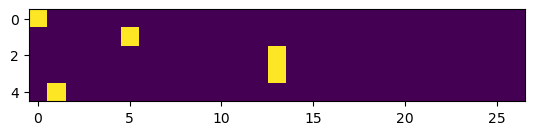

In [116]:
import matplotlib.pyplot as plt
plt.imshow(xenc)

In [117]:
xenc.dtype

torch.float32

In [223]:
W = torch.randn((27, 27))
xenc @ W    # without any bias , just random weights with xenc
# dot product multiplites and adds so basically for one 's' it takes the one hot encoding and mulitplies with W for that index and then sums for all 27

tensor([[ 1.2933, -0.2096,  1.9409, -1.4356,  0.0186, -0.6571, -0.4344,  0.2570,
          1.1237,  0.4235,  0.7946, -0.0748, -0.3471,  0.2588, -0.8406,  0.1917,
         -2.4014,  0.2777, -1.8655, -1.2903,  1.2234,  0.9817, -0.0755, -1.5448,
          0.0671,  2.0935,  0.6207],
        [ 0.2901, -0.0244, -0.0548, -0.2931, -1.1101, -2.1215,  1.4585, -0.5117,
         -0.6482,  0.4511,  1.4926, -0.2587,  0.9235,  0.7968,  0.7546, -0.9452,
         -1.7037, -0.8894,  0.4130, -0.9865, -0.0621,  0.0865, -1.5052,  1.1530,
          1.2114, -0.3440, -0.6267],
        [-1.1798, -0.9922,  0.1994,  0.7531, -1.5577,  1.1976,  0.1535,  1.8903,
         -0.5525, -0.5845,  0.3168, -0.1621,  1.4944,  1.6282, -0.2131, -0.1793,
          2.9483,  0.0992, -1.7645, -2.0110,  2.7215, -1.2741,  0.8128,  0.5525,
          1.2199, -1.4172, -1.0834],
        [-1.1798, -0.9922,  0.1994,  0.7531, -1.5577,  1.1976,  0.1535,  1.8903,
         -0.5525, -0.5845,  0.3168, -0.1621,  1.4944,  1.6282, -0.2131, -0.1793

Each dot product output represents the "firing rate" or signal strength of a specific neuron for a given input, which then influences the final prediction

In [226]:
xenc.shape, W.shape , (xenc @ W).shape

(torch.Size([5, 27]), torch.Size([27, 27]), torch.Size([5, 27]))

In [228]:
logits = xenc @ W # log-counts
counts = logits.exp() # equivalent N
probs = counts / counts.sum(1, keepdims=True)
probs

tensor([[0.0782, 0.0174, 0.1494, 0.0051, 0.0219, 0.0111, 0.0139, 0.0277, 0.0660,
         0.0328, 0.0475, 0.0199, 0.0152, 0.0278, 0.0093, 0.0260, 0.0019, 0.0283,
         0.0033, 0.0059, 0.0729, 0.0572, 0.0199, 0.0046, 0.0229, 0.1740, 0.0399],
        [0.0367, 0.0268, 0.0260, 0.0205, 0.0090, 0.0033, 0.1181, 0.0165, 0.0144,
         0.0431, 0.1222, 0.0212, 0.0691, 0.0609, 0.0584, 0.0107, 0.0050, 0.0113,
         0.0415, 0.0102, 0.0258, 0.0299, 0.0061, 0.0870, 0.0922, 0.0195, 0.0147],
        [0.0042, 0.0050, 0.0165, 0.0288, 0.0029, 0.0449, 0.0158, 0.0897, 0.0078,
         0.0076, 0.0186, 0.0115, 0.0604, 0.0690, 0.0109, 0.0113, 0.2584, 0.0150,
         0.0023, 0.0018, 0.2060, 0.0038, 0.0305, 0.0235, 0.0459, 0.0033, 0.0046],
        [0.0042, 0.0050, 0.0165, 0.0288, 0.0029, 0.0449, 0.0158, 0.0897, 0.0078,
         0.0076, 0.0186, 0.0115, 0.0604, 0.0690, 0.0109, 0.0113, 0.2584, 0.0150,
         0.0023, 0.0018, 0.2060, 0.0038, 0.0305, 0.0235, 0.0459, 0.0033, 0.0046],
        [0.0022, 0.0084,

In [230]:
probs.sum(1)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

In [123]:
# (5, 27) @ (27, 27) -> (5, 27)

### how logits work (with simple example)

In [232]:
xsam = torch.tensor([1,0,0,0]).float()
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((4, 4), generator=g)
logits = xsam @ W

In [234]:
counts = logits.exp()
counts

tensor([4.7940, 0.7888, 0.9730, 0.3326])

In [236]:
probs = counts / counts.sum() 

In [238]:
probs

tensor([0.6960, 0.1145, 0.1413, 0.0483])

In [240]:
probs.sum()

tensor(1.0000)

## clean neuron

In [242]:
xs , ys

(tensor([ 0,  5, 13, 13,  1]), tensor([ 5, 13, 13,  1,  0]))

In [244]:
# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g)

In [246]:
xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
logits = xenc @ W # predict log-counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
# btw: the last 2 lines here are together called a 'softmax'

In [248]:
probs.shape

torch.Size([5, 27])

In [251]:

nlls = torch.zeros(5)
for i in range(5):
  # i-th bigram:
  x = xs[i].item() # input character index
  y = ys[i].item() # label character index
  print('--------')
  print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y]
  print('probability assigned by the net to the the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])
label (actual next character): 5
probability assigned by the net to the the correct character: 0.01228625513613224
log likelihood: -4.399273872375488
negative log likelihood: 4.399273872375488
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472])
label (actual next character): 13
probability assigned by the net to the the correct character: 0.

## Optimization

for optimization we need forward pass, loss and backward pass

In [454]:
xs,ys

(tensor([ 0,  5, 13, 13,  1]), tensor([ 5, 13, 13,  1,  0]))

In [456]:
xs.shape,ys.shape

(torch.Size([5]), torch.Size([5]))

In [541]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad = True)

In [332]:
# forward pass
xenc = F.one_hot(xs, num_classes = 27).float()
logits = xenc @ W
count = logits.exp()
probs = count/count.sum(1,keepdims = True)

In [334]:
probs

tensor([[0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
         0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
         0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459],
        [0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
         0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
         0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472],
        [0.0312, 0.0737, 0.0484, 0.0333, 0.0674, 0.0200, 0.0263, 0.0249, 0.1226,
         0.0164, 0.0075, 0.0789, 0.0131, 0.0267, 0.0147, 0.0112, 0.0585, 0.0121,
         0.0650, 0.0058, 0.0208, 0.0078, 0.0133, 0.0203, 0.1204, 0.0469, 0.0126],
        [0.0312, 0.0737, 0.0484, 0.0333, 0.0674, 0.0200, 0.0263, 0.0249, 0.1226,
         0.0164, 0.0075, 0.0789, 0.0131, 0.0267, 0.0147, 0.0112, 0.0585, 0.0121,
         0.0650, 0.0058, 0.0208, 0.0078, 0.0133, 0.0203, 0.1204, 0.0469, 0.0126],
        [0.0150, 0.0086,

In [336]:
probs[0,5] , probs[1,13] , probs[2,13] , probs[3,1], probs[4,0]

(tensor(0.0123, grad_fn=<SelectBackward0>),
 tensor(0.0181, grad_fn=<SelectBackward0>),
 tensor(0.0267, grad_fn=<SelectBackward0>),
 tensor(0.0737, grad_fn=<SelectBackward0>),
 tensor(0.0150, grad_fn=<SelectBackward0>))

In [338]:
probs[torch.arange(5) , ys]

tensor([0.0123, 0.0181, 0.0267, 0.0737, 0.0150], grad_fn=<IndexBackward0>)

In [326]:
#loss function

In [348]:
# avg neg log likelihood
loss = -probs[torch.arange(5) , ys].log().mean()
loss.item()

3.7693049907684326

In [382]:
#backward pass
W.grad = None # set it to 0 or None
loss.backward()

In [384]:
W.grad[1], W.grad[3] # gets updated for . e m m a  weight representation alone thats why others are still 0

(tensor([-0.1968,  0.0017,  0.0079,  0.0020,  0.0121,  0.0062,  0.0216,  0.0026,
          0.0025,  0.0010,  0.0204,  0.0017,  0.0197,  0.0022,  0.0046,  0.0041,
          0.0082,  0.0016,  0.0179,  0.0106,  0.0093,  0.0062,  0.0010,  0.0066,
          0.0131,  0.0101,  0.0018]),
 tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.]))

In [386]:
W.data += -0.1 * W.grad

In [388]:
# forward pass again
xenc = F.one_hot(xs, num_classes = 27).float()
logits = xenc @ W
count = logits.exp()
probs = count/count.sum(1,keepdims = True)

In [390]:
# avg neg log likelihood again
loss = -probs[torch.arange(5) , ys].log().mean()
loss.item()

3.6891682147979736

### Optimization but with full dataset (not just .emma)

In [556]:
xs,ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        xs.append(stoi[ch1])
        ys.append(stoi[ch2])
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
num

228146

In [560]:
xs

tensor([ 0,  5, 13,  ..., 25, 26, 24])

In [562]:
xenc = F.one_hot(xs, num_classes = 27).float()

In [572]:
xenc.shape, xs.shape,ys.shape, (xenc @ W).shape, probs.shape

(torch.Size([228146, 27]),
 torch.Size([228146]),
 torch.Size([228146]),
 torch.Size([228146, 27]),
 torch.Size([228146, 27]))

In [551]:
for i in range(20):
    #forward pass
    xenc = F.one_hot(xs, num_classes = 27).float()
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1,keepdims = True)

    #loss function
    loss = -probs[torch.arange(num),ys].log().mean() + 0.1 *(W**2).mean() # regularization loss - it should force the model to reach to 0 but it should also come near zero with our probabolity 
    print(loss.item())

    #backward pass
    W.grad = None
    loss.backward()

    #update
    W.data += -50 * W.grad   # -0.1 to go against the dir of gradient to minimze loss 
    
    

2.588892698287964
2.588792562484741
2.5886967182159424
2.5886049270629883
2.588517189025879
2.588433265686035
2.588353395462036
2.5882763862609863
2.588202953338623
2.588132619857788
2.5880649089813232
2.5880002975463867
2.5879385471343994
2.587878942489624
2.587822198867798
2.5877676010131836
2.587714910507202
2.587664842605591
2.587616443634033
2.5875701904296875


In [525]:
xs.shape, xenc.shape , probs.shape , W.shape 

(torch.Size([228146]),
 torch.Size([228146, 27]),
 torch.Size([228146, 27]),
 torch.Size([27, 27]))

[our loss from count](#loss-count) and this loss from neural net comparison
(2.4544) and 2.598834753036499

Regularization is a technique used to influence the model's parameters and prevent them from becoming too extreme, effectively serving as a form of **model smoothing** [P = (N+1).float()](#smoothing) (1:50:18). 

* **Weight Penalty:** By adding a component to the loss function based on the size of the weights (like the mean of squared weights), we penalize large values (1:52:10). This creates a 'force' that pushes the weights toward zero.
* **Balancing Goals:** The training process then attempts to minimize both the **negative log-likelihood** (to fit the data) and the **regularization loss** (to keep weights small). This prevents the model from over-relying on specific, potentially noisy patterns in the training set (1:53:14).
* **Controlling Smoothness:** The **regularization strength** acts as a knob; a higher value forces the weights toward zero, resulting in a more uniform and 'smooth' probability distribution, similar to adding 'fake counts' to a count matrix (1:53:49).

In [498]:
(W**2).mean() , (W**2).sum() , 0.1 *(W**2).mean()

(tensor(1.6347, grad_fn=<MeanBackward0>),
 tensor(1191.6769, grad_fn=<SumBackward0>),
 tensor(0.1635, grad_fn=<MulBackward0>))

In [553]:
# finally, sample from the 'neural net' model
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  
  out = []
  ix = 0
  while True:
    
    # ----------
    # BEFORE:
    #p = P[ix]
    # ----------
    # NOW:
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------
    
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

junide.
janaqah.
p.
cfay.
a.


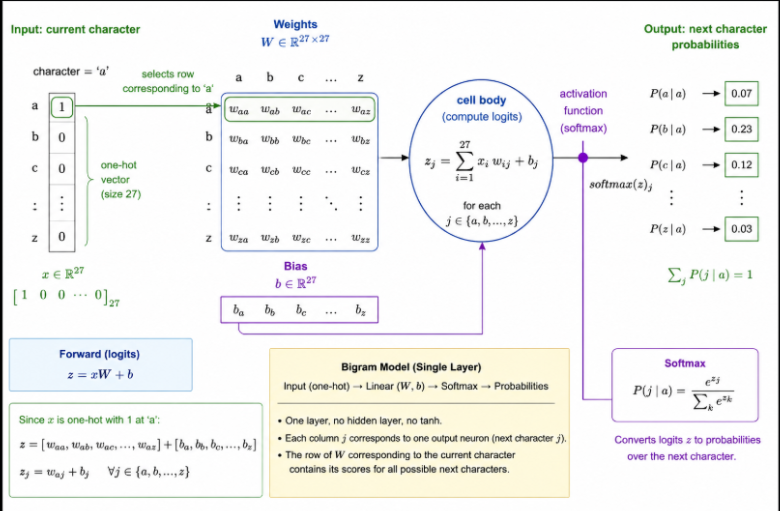